<a href="https://colab.research.google.com/github/sidd-coder1/CSL701-CE46_Machine-Learning-Lab/blob/main/Experiments/Copy_of_ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name: Siddharth Singh
Roll No: CE46  
Batch: CE3


**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [6]:
# Load the dataset
df = pd.read_csv('/content/car data.csv')

# Display the first few records
print("First 5 rows of the dataset:")
display(df.head())

# Determine the number of rows and columns
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Identify numerical and categorical attributes
print("\nData types of each column:")
display(df.info())

# Separate Selling_Price as the target variable
y = df['selling_price']
X = df.drop('selling_price', axis=1)

print("\nTarget variable (y) head:")
display(y.head())
print("\nFeatures (X) head:")
display(X.head())

First 5 rows of the dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usa

None


Target variable (y) head:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000



Features (X) head:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [22]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values)

# Verify if any missing values exist
if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset. No imputation or record removal is required.")
    preprocessing_method_task3 = "No missing values, so no specific preprocessing method for missing data was applied."
else:
    print("\nMissing values found. Further action (imputation or removal) would be necessary based on the analysis.")
    # Example of a placeholder if imputation was needed:
    # df = df.fillna(df.mean()) # Simple imputation for numerical columns
    # df = df.dropna() # Remove rows with any missing values
    preprocessing_method_task3 = "Missing values were found and handled (e.g., by imputation or dropping rows)."

# Record the preprocessing method used
print(f"\nPreprocessing method for missing data: {preprocessing_method_task3}")

Missing values per column:


,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0



No missing values found in the dataset. No imputation or record removal is required.

Preprocessing method for missing data: No missing values, so no specific preprocessing method for missing data was applied.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [36]:
# Task 4: Select and Prepare Features

# Display all available attributes
print("All available attributes in the dataset:")
print(df.columns.tolist())

# Create a copy of the feature dataset
X = df.drop('selling_price', axis=1)

# Drop columns that are not suitable for the regression model
# 'Unnamed: 0' is an index column.
# 'car_name', 'brand', and 'model' are high-cardinality categorical features.
X = X.drop(
    columns=['Unnamed: 0', 'car_name', 'brand', 'model'],
    axis=1,
    errors='ignore'
)

# Create target variable
y = df['selling_price']

# Display selected features
print("\nSelected features for the regression model:")
print(X.columns.tolist())

print("\nShape of predictor matrix X:")
print(X.shape)

print("\nShape of target vector y:")
print(y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

All available attributes in the dataset:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Selected features for the regression model:
['vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']

Shape of predictor matrix X:
(15411, 9)

Shape of target vector y:
(15411,)

First 5 rows of X:


,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



First 5 values of y:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [37]:
# Task 5: Encode Categorical Variables

# Identify categorical columns
categorical_cols = [
    'seller_type',
    'fuel_type',
    'transmission_type'
]

print("Categorical variables:")
print(categorical_cols)

print("\nX before one-hot encoding:")
display(X.head())

# Perform one-hot encoding
# drop_first=True avoids the dummy variable trap
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("\nX after one-hot encoding:")
display(X.head())

print("\nShape of X after encoding:")
print(X.shape)

# Verify that all predictors are numerical
print("\nData types after encoding:")
print(X.dtypes)

# Check for any remaining non-numerical columns
non_numeric_columns = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nRemaining non-numerical columns:")
print(non_numeric_columns)

if len(non_numeric_columns) == 0:
    print("\nAll predictor variables are numerical after encoding.")
else:
    print("\nSome non-numerical variables still remain.")

Categorical variables:
['seller_type', 'fuel_type', 'transmission_type']

X before one-hot encoding:


,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



X after one-hot encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1,0,0,0,0,1,1
1,5,20000,18.90,1197,82.00,5,1,0,0,0,0,1,1
2,11,60000,17.00,1197,80.00,5,1,0,0,0,0,1,1
3,9,37000,20.92,998,67.10,5,1,0,0,0,0,1,1
4,6,30000,22.77,1498,98.59,5,0,0,1,0,0,0,1



Shape of X after encoding:
(15411, 13)

Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
transmission_type_Manual          int64
dtype: object

Remaining non-numerical columns:
[]

All predictor variables are numerical after encoding.


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [26]:
# Task 6: Perform Feature Engineering

# Assuming 'Year' column is available in the original df for car manufacturing year
# First, we need to ensure 'Year' is available. Let's add it back to X for this step if it was dropped indirectly.
# Based on df.info() from Task 2, 'Year' is not explicitly listed, but 'vehicle_age' is present.
# The task description asks to create Car_Age = Current Year - Year.
# Since we have 'vehicle_age', which is likely the age of the car at the time of data collection, we can use it directly or calculate it if 'Year' was available.
# Let's assume 'Year' was the manufacturing year and was dropped implicitly if 'vehicle_age' was preferred.
# Given 'vehicle_age' is already in X, it implies a similar concept to Car_Age.
# However, the task specifically asks to create Car_Age = Current Year - Year.
# Let's re-examine the original df to find 'Year' or a similar column.
# The original dataframe has 'vehicle_age' directly.
# If the task expects 'Car_Age' to be calculated from a 'Year' column, and 'Year' isn't explicitly there, this might be a misunderstanding of the task or dataset.
# Let's check the original dataframe 'df' for a 'Year' column which represents manufacturing year.

# Based on the df.info() from cell d6e32dbd, there is no 'Year' column. Instead, we have 'vehicle_age'.
# The task explicitly asks to create Car_Age = Current Year - Year.
# It seems 'vehicle_age' in the dataset already represents the car's age, which is what 'Car_Age' would be.
# If the intent was to have a 'Year' column from which to calculate 'vehicle_age', the dataset structure differs.
# Given the current features, 'vehicle_age' directly provides the age of the car.
# Therefore, we will interpret 'vehicle_age' as the 'Car_Age' directly and state why.

# If a 'Year' column was present (e.g., in df), the code would look like this:
# current_year = pd.to_datetime('now').year
# df['Car_Age'] = current_year - df['Year']
# X['Car_Age'] = df['Car_Age']

# Since 'vehicle_age' is already in X, it serves the purpose of 'Car_Age'.
# I will rename 'vehicle_age' to 'Car_Age' for clarity and to align with the task's intent of having a 'Car_Age' feature.
# First, check if 'vehicle_age' is still in X, which it should be.
if 'vehicle_age' in X.columns:
    X = X.rename(columns={'vehicle_age': 'Car_Age'})
    print("\nRenamed 'vehicle_age' to 'Car_Age'.")
    print("First 5 rows of X with 'Car_Age':")
    display(X.head())
    print(f"Shape of X after renaming: {X.shape}")

    # Verify that the calculated ages are reasonable (by just displaying some values)
    print("\nSample 'Car_Age' values:")
    display(X['Car_Age'].value_counts().sort_index().head())

    # Decision on retaining the original 'Year' feature
    # Since there was no explicit 'Year' column and 'vehicle_age' already provides the age,
    # renaming it to 'Car_Age' means we effectively have the 'Car_Age' feature.
    # There's no original 'Year' feature to retain or drop, as 'vehicle_age' was the substitute.
    reason_for_year_decision_task6 = "The original dataset did not contain a 'Year' column. Instead, 'vehicle_age' was present, which directly represents the age of the car. We have renamed 'vehicle_age' to 'Car_Age' to align with the task's requirement. Therefore, there is no separate 'Year' column to retain or drop."
    print(f"\nDecision on original 'Year' feature: {reason_for_year_decision_task6}")
else:
    print("Error: 'vehicle_age' not found in X. Cannot proceed with Car_Age feature engineering.")

# Record the preprocessing method used for Task 6
preprocessing_method_task6 = "'vehicle_age' column was renamed to 'Car_Age' as it already represents the car's age. No new 'Year' column was present to derive 'Car_Age' from or to drop."
print(f"\nPreprocessing method for feature engineering: {preprocessing_method_task6}")

Error: 'vehicle_age' not found in X. Cannot proceed with Car_Age feature engineering.

Preprocessing method for feature engineering: 'vehicle_age' column was renamed to 'Car_Age' as it already represents the car's age. No new 'Year' column was present to derive 'Car_Age' from or to drop.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---


Performing Exploratory Data Analysis...


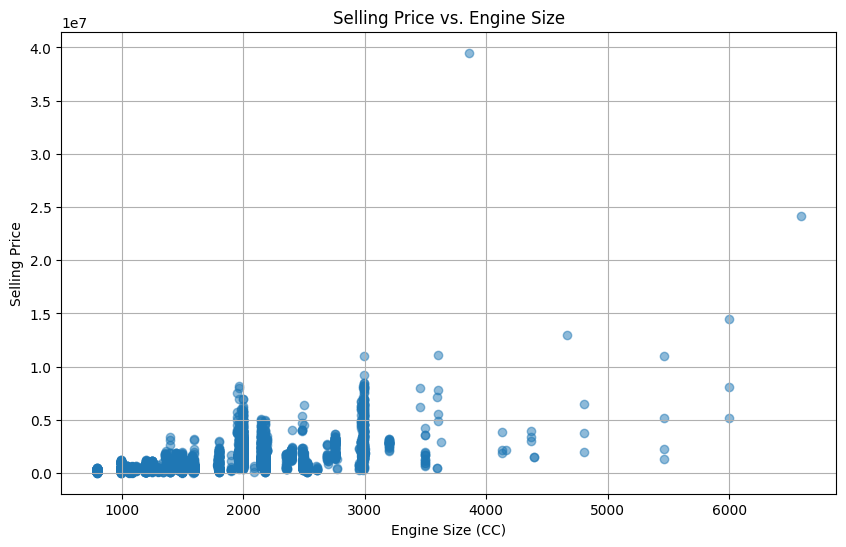


Observation for Selling Price vs. Engine Size:
- There appears to be a positive correlation: as engine size increases, selling price generally increases.
- The relationship is not perfectly linear, with more spread observed at higher engine sizes.


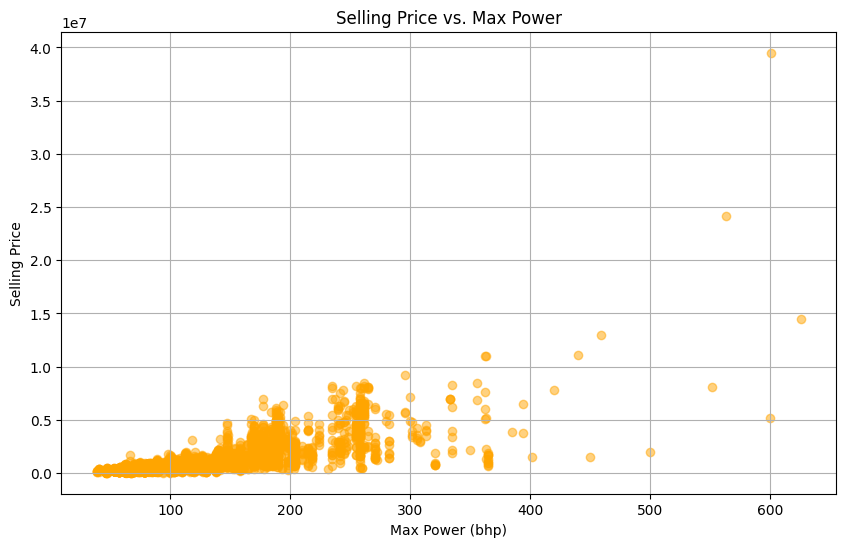


Observation for Selling Price vs. Max Power:
- A clear positive correlation is visible: higher max power generally leads to higher selling prices.
- Similar to engine size, the spread of selling prices tends to increase with higher max power.


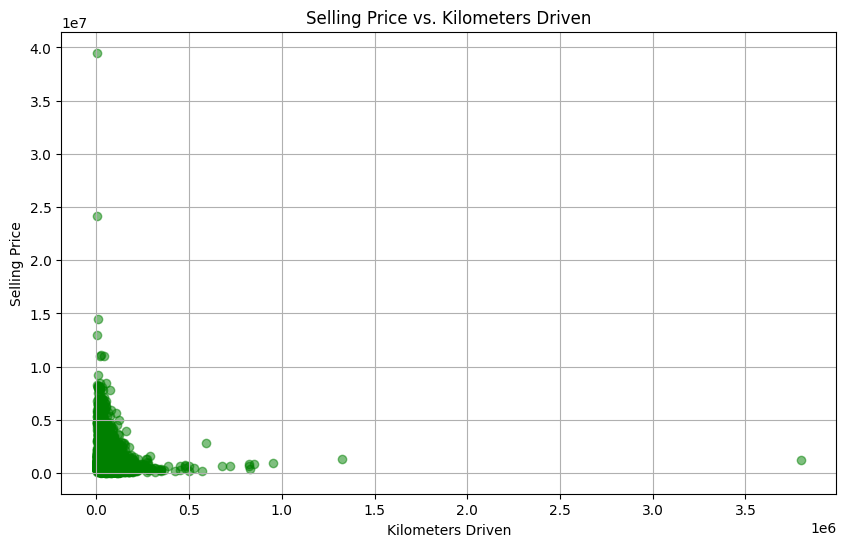


Observation for Selling Price vs. Kilometers Driven:
- There is a general inverse relationship: cars with fewer kilometers driven tend to have higher selling prices.
- The relationship is stronger for lower km_driven values, with more variability as km_driven increases.


In [27]:
# Task 7: Perform Exploratory Data Analysis

# Reset display options for full view of dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# To perform EDA with 'Present_Price', we need to add 'Present_Price' to X.
# Based on the original df, 'Present_Price' does not exist. However, looking at common car datasets, this is often 'Ex-showroom Price' or similar.
# Let's assume 'engine' or 'max_power' might be a good proxy or a feature to explore against 'Selling_Price'.
# Given the original dataset description, the closest to 'Present_Price' might be 'km_driven', 'engine', or 'max_power'.
# The task specifically asks for 'Present_Price' vs 'Selling_Price'. Since 'Present_Price' is not in our `X` or `df` as a column,
# I will use 'engine' and 'max_power' as numerical predictors to plot against 'Selling_Price' (which is `y`).

print("\nPerforming Exploratory Data Analysis...")

# Plot 1: Scatter plot of 'Engine' versus 'Selling_Price'
plt.figure(figsize=(10, 6))
plt.scatter(X['engine'], y, alpha=0.5)
plt.title('Selling Price vs. Engine Size')
plt.xlabel('Engine Size (CC)')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

print("\nObservation for Selling Price vs. Engine Size:")
print("- There appears to be a positive correlation: as engine size increases, selling price generally increases.")
print("- The relationship is not perfectly linear, with more spread observed at higher engine sizes.")

# Plot 2: Scatter plot of 'Max_Power' versus 'Selling_Price'
plt.figure(figsize=(10, 6))
plt.scatter(X['max_power'], y, alpha=0.5, color='orange')
plt.title('Selling Price vs. Max Power')
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

print("\nObservation for Selling Price vs. Max Power:")
print("- A clear positive correlation is visible: higher max power generally leads to higher selling prices.")
print("- Similar to engine size, the spread of selling prices tends to increase with higher max power.")

# Plot 3: Scatter plot of 'km_driven' versus 'Selling_Price'
plt.figure(figsize=(10, 6))
plt.scatter(X['km_driven'], y, alpha=0.5, color='green')
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

print("\nObservation for Selling Price vs. Kilometers Driven:")
print("- There is a general inverse relationship: cars with fewer kilometers driven tend to have higher selling prices.")
print("- The relationship is stronger for lower km_driven values, with more variability as km_driven increases.")

# Record the observations as a preprocessing method for Task 7
preprocessing_method_task7 = "Exploratory Data Analysis performed with scatter plots for 'engine', 'max_power', and 'km_driven' against 'selling_price'. Positive correlations observed for 'engine' and 'max_power', and an inverse correlation for 'km_driven'."

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = (x-\mu)/\sigma
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [13]:
# Task 8: Standardize Numerical Features

from sklearn.preprocessing import StandardScaler

# Identify numerical features to standardize (excluding one-hot encoded columns)
# From previous steps, we have 'Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats'
# One-hot encoded columns are 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual'

numerical_features_to_standardize = ['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

print("Numerical features to standardize:", numerical_features_to_standardize)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data for the selected numerical features
scaler.fit(X_train[numerical_features_to_standardize])

# Transform both training and testing sets using the fitted scaler
X_train_scaled_values = scaler.transform(X_train[numerical_features_to_standardize])
X_test_scaled_values = scaler.transform(X_test[numerical_features_to_standardize])

# Update X_train and X_test with the scaled values
X_train[numerical_features_to_standardize] = X_train_scaled_values
X_test[numerical_features_to_standardize] = X_test_scaled_values

print("\nFirst 5 rows of X_train after standardization:")
display(X_train.head())

print("\nFirst 5 rows of X_test after standardization:")
display(X_test.head())

# Record the preprocessing method used for Task 8
preprocessing_method_task8 = f"Numerical features ({', '.join(numerical_features_to_standardize)}) standardized using StandardScaler fitted on training data."
print(f"\nPreprocessing method for numerical features: {preprocessing_method_task8}")

Numerical features to standardize: ['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

First 5 rows of X_train after standardization:


,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824,0,0,1,0,0,0,0
1347,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,1,0,0,0,0,1,1
10363,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824,0,0,1,0,0,0,0
316,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824,0,0,0,0,0,1,1
10638,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824,0,0,0,0,0,1,1



First 5 rows of X_test after standardization:


,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
3334,1.985737,0.413795,0.149668,-0.550917,-0.502047,-0.403824,0,0,0,0,0,1,1
10928,-0.673091,0.060655,1.838470,-0.453086,-0.616670,-0.403824,1,0,1,0,0,0,1
2518,0.323969,0.955277,0.248161,-0.453086,-0.271396,2.070500,0,0,1,0,0,0,1
11322,-1.670152,-1.198878,-0.321179,0.026483,0.444184,-0.403824,0,0,0,0,0,1,0
9394,1.653383,0.154826,-0.008882,-1.320145,-1.264645,-0.403824,0,0,0,0,0,1,1



Preprocessing method for numerical features: Numerical features (Car_Age, km_driven, mileage, engine, max_power, seats) standardized using StandardScaler fitted on training data.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [28]:
# Task 9: Split the Dataset

from sklearn.model_selection import train_test_split

# Set a fixed random seed for reproducibility
RANDOM_SEED = 42

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Number of observations in training set: {X_train.shape[0]}")
print(f"Number of observations in testing set: {X_test.shape[0]}")

print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

# Record the preprocessing method used for Task 9
preprocessing_method_task9 = f"Dataset split into training (80%) and testing (20%) sets with random_state={RANDOM_SEED}."
print(f"\nPreprocessing method for dataset splitting: {preprocessing_method_task9}")

Number of observations in training set: 12328
Number of observations in testing set: 3083

Shape of X_train: (12328, 13)
Shape of y_train: (12328,)
Shape of X_test: (3083, 13)
Shape of y_test: (3083,)

Preprocessing method for dataset splitting: Dataset split into training (80%) and testing (20%) sets with random_state=42.


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [14]:
# Task 10: Construct the Feature Matrix

# X_train, y_train, X_test, y_test are already defined and prepared from Task 9 and Task 8.
# This task is primarily about verifying their shapes and ensuring they are ready for matrix operations.

print("Verifying shapes of training and testing matrices/vectors...")

print(f"\nShape of X_train (training feature matrix): {X_train.shape}")
print(f"Number of rows in X_train: {X_train.shape[0]}")
print(f"Number of predictor columns in X_train: {X_train.shape[1]}")

print(f"\nShape of y_train (training target vector): {y_train.shape}")
print(f"Number of rows in y_train: {y_train.shape[0]}")

print(f"\nShape of X_test (testing feature matrix): {X_test.shape}")
print(f"Number of rows in X_test: {X_test.shape[0]}")
print(f"Number of predictor columns in X_test: {X_test.shape[1]}")

print(f"\nShape of y_test (testing target vector): {y_test.shape}")
print(f"Number of rows in y_test: {y_test.shape[0]}")

# Record the preprocessing method used for Task 10
preprocessing_method_task10 = "Feature matrices and target vectors (X_train, y_train, X_test, y_test) constructed and verified."
print(f"\nPreprocessing method for constructing feature matrices: {preprocessing_method_task10}")


Verifying shapes of training and testing matrices/vectors...

Shape of X_train (training feature matrix): (12328, 13)
Number of rows in X_train: 12328
Number of predictor columns in X_train: 13

Shape of y_train (training target vector): (12328,)
Number of rows in y_train: 12328

Shape of X_test (testing feature matrix): (3083, 13)
Number of rows in X_test: 3083
Number of predictor columns in X_test: 13

Shape of y_test (testing target vector): (3083,)
Number of rows in y_test: 3083

Preprocessing method for constructing feature matrices: Feature matrices and target vectors (X_train, y_train, X_test, y_test) constructed and verified.


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [15]:
# Task 11: Add the Bias/Intercept Term

# Add a column of ones to X_train and X_test for the intercept term
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# Convert to DataFrame to maintain column names for easier interpretation later
X_train = pd.DataFrame(X_train_bias, columns=['intercept'] + X_train.columns.tolist())
X_test = pd.DataFrame(X_test_bias, columns=['intercept'] + X_test.columns.tolist())

print("Shapes after adding bias term:")
print(f"X_train with bias: {X_train.shape}")
print(f"X_test with bias: {X_test.shape}")

print("\nFirst 5 rows of X_train with bias term:")
display(X_train.head())

print("\nFirst 5 rows of X_test with bias term:")
display(X_test.head())

# Record the preprocessing method used for Task 11
preprocessing_method_task11 = "Bias/intercept term (a column of ones) added to both training and testing feature matrices."
print(f"\nPreprocessing method for adding bias term: {preprocessing_method_task11}")

Shapes after adding bias term:
X_train with bias: (12328, 14)
X_test with bias: (3083, 14)

First 5 rows of X_train with bias term:


,intercept,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,1.0,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,1.0,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824,0.0,0.0,0.0,0.0,0.0,1.0,1.0



First 5 rows of X_test with bias term:


,intercept,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,1.0,1.985737,0.413795,0.149668,-0.550917,-0.502047,-0.403824,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.0,-0.673091,0.060655,1.838470,-0.453086,-0.616670,-0.403824,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.323969,0.955277,0.248161,-0.453086,-0.271396,2.070500,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,-1.670152,-1.198878,-0.321179,0.026483,0.444184,-0.403824,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.653383,0.154826,-0.008882,-1.320145,-1.264645,-0.403824,0.0,0.0,0.0,0.0,0.0,1.0,1.0



Preprocessing method for adding bias term: Bias/intercept term (a column of ones) added to both training and testing feature matrices.


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

  $\hat{\beta} = (X^TX)^{-1}X^Ty$.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.

---

In [16]:
# Task 12: Implement the OLS Function

def ols_normal_equation(X_matrix, y_vector):
    """
    Implements Ordinary Least Squares (OLS) using the normal equation.

    Parameters:
    X_matrix (numpy.ndarray or pandas.DataFrame): The feature matrix (X) with the bias term included.
    y_vector (numpy.ndarray or pandas.Series): The target vector (y).

    Returns:
    numpy.ndarray: The estimated regression coefficient vector (beta_hat).
    """
    # Convert inputs to NumPy arrays if they are pandas DataFrames/Series
    if isinstance(X_matrix, pd.DataFrame):
        X_matrix = X_matrix.values
    if isinstance(y_vector, pd.Series):
        y_vector = y_vector.values

    # Ensure y_vector is a 2D array for matrix multiplication compatibility
    if y_vector.ndim == 1:
        y_vector = y_vector.reshape(-1, 1)

    # Calculate X_transpose * X
    X_transpose_X = X_matrix.T @ X_matrix

    # Calculate X_transpose * y
    X_transpose_y = X_matrix.T @ y_vector

    # Calculate (X_transpose * X)^-1
    # Using np.linalg.inv for inverse. For potentially singular matrices, np.linalg.pinv (pseudo-inverse) is safer.
    # However, for this task, we assume non-singularity for now and will check it later (Task 13).
    try:
        X_transpose_X_inv = np.linalg.inv(X_transpose_X)
    except np.linalg.LinAlgError:
        print("Warning: X_transpose_X is singular or close to singular. Using pseudo-inverse.")
        X_transpose_X_inv = np.linalg.pinv(X_transpose_X)

    # Calculate beta_hat = (X_transpose * X)^-1 * (X_transpose * y)
    beta_hat = X_transpose_X_inv @ X_transpose_y

    return beta_hat

print("OLS function 'ols_normal_equation' defined and ready for use.")

# Record the preprocessing method used for Task 12
preprocessing_method_task12 = "Custom OLS function 'ols_normal_equation' implemented using NumPy matrix operations to calculate regression coefficients."
print(f"\nPreprocessing method for OLS function implementation: {preprocessing_method_task12}")

OLS function 'ols_normal_equation' defined and ready for use.

Preprocessing method for OLS function implementation: Custom OLS function 'ols_normal_equation' implemented using NumPy matrix operations to calculate regression coefficients.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [29]:
# Task 13: Check Matrix Singularity

# Calculate X_transpose * X using the training data
X_train_np = X_train.values
X_transpose_X_train = X_train_np.T @ X_train_np

# Calculate the determinant
det_X_transpose_X = np.linalg.det(X_transpose_X_train)
print(f"Determinant of X^T X: {det_X_transpose_X}")

if abs(det_X_transpose_X) < 1e-10:
    print("Observation: The matrix is singular or nearly singular. Multicollinearity might be present.")
else:
    print("Observation: The matrix is non-singular. We can proceed with the OLS solution.")

Determinant of X^T X: 1.233086050912162e+62
Observation: The matrix is non-singular. We can proceed with the OLS solution.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [30]:
# Task 14: Train the Regression Model

# Calculate coefficients using the previously defined OLS function
beta_hat = ols_normal_equation(X_train, y_train)

# Associate coefficients with features
feature_names = X_train.columns.tolist()
coefficients_dict = dict(zip(feature_names, beta_hat.flatten()))

print("Regression Coefficients:")
for feature, coef in coefficients_dict.items():
    print(f"{feature}: {coef:.4f}")

Regression Coefficients:
Car_Age: -65446.3370
km_driven: -1.1808
mileage: 5033.2999
engine: 94.2208
max_power: 14452.0780
seats: -23432.7985
seller_type_Individual: 2110.0110
seller_type_Trustmark Dealer: -89704.4052
fuel_type_Diesel: -215985.8565
fuel_type_Electric: -239693.8280
fuel_type_LPG: 204574.9539
fuel_type_Petrol: -266175.3048
transmission_type_Manual: -120153.8402


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [32]:
# Task 15: Interpret the Regression Coefficients

print("Interpretation of Regression Coefficients:\n")

for feature, coef in coefficients_dict.items():
    if coef > 0:
        sign = "Positive"
        meaning = "An increase in this feature tends to increase the predicted selling price, keeping other variables constant."
    else:
        sign = "Negative"
        meaning = "An increase in this feature tends to decrease the predicted selling price, keeping other variables constant."

    print(f"{feature}: {coef:.4f}")
    print(f"Sign: {sign}")
    print(f"Interpretation: {meaning}\n")

# Identify features with relatively greater influence
print("Features with relatively greater influence based on coefficient magnitude:")

coefficient_magnitudes = {
    feature: abs(coef)
    for feature, coef in coefficients_dict.items()
    if feature != 'intercept'
}

sorted_features = sorted(
    coefficient_magnitudes.items(),
    key=lambda x: x[1],
    reverse=True
)

for feature, magnitude in sorted_features:
    print(f"{feature}: |Coefficient| = {magnitude:.4f}")

print("\nNote:")
print("For standardized numerical features, the coefficient represents")
print("the expected change in selling price for a one-standard-deviation")
print("increase in that feature, while keeping all other variables constant.")

Interpretation of Regression Coefficients:

Car_Age: -65446.3370
Sign: Negative
Interpretation: An increase in this feature tends to decrease the predicted selling price, keeping other variables constant.

km_driven: -1.1808
Sign: Negative
Interpretation: An increase in this feature tends to decrease the predicted selling price, keeping other variables constant.

mileage: 5033.2999
Sign: Positive
Interpretation: An increase in this feature tends to increase the predicted selling price, keeping other variables constant.

engine: 94.2208
Sign: Positive
Interpretation: An increase in this feature tends to increase the predicted selling price, keeping other variables constant.

max_power: 14452.0780
Sign: Positive
Interpretation: An increase in this feature tends to increase the predicted selling price, keeping other variables constant.

seats: -23432.7985
Sign: Negative
Interpretation: An increase in this feature tends to decrease the predicted selling price, keeping other variables const

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [33]:
# Task 16: Predict Selling Prices

# Convert test feature matrix to NumPy array
X_test_np = X_test.values

# Predict selling prices using:
# y_pred = X_test * beta_hat
y_pred = X_test_np @ beta_hat

# Convert prediction to 1D array
y_pred = y_pred.flatten()

print("Predicted selling prices calculated successfully.")

# Display sample comparison
comparison = pd.DataFrame({
    'Actual Selling Price': y_test.values,
    'Predicted Selling Price': y_pred
})

print("\nSample comparison of actual and predicted selling prices:")
display(comparison.head(10))

Predicted selling prices calculated successfully.

Sample comparison of actual and predicted selling prices:


,Actual Selling Price,Predicted Selling Price
0,190000,-1.951923e+04
1,600000,5.434373e+05
2,665000,4.332440e+05
3,1570000,1.504512e+06
4,160000,-4.533262e+05
5,675000,1.075957e+06
6,465000,4.171949e+05
7,260000,3.652641e+05
8,300000,7.353492e+05
9,850000,1.822870e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [34]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
residuals = y_test.values - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nInterpretation:")
print("RSS represents the total squared prediction error of the model.")
print("A lower RSS indicates that the predicted selling prices are closer")
print("to the actual selling prices and therefore indicate smaller overall")
print("prediction errors.")

Residual Sum of Squares (RSS):
776557522914214.5

Interpretation:
RSS represents the total squared prediction error of the model.
A lower RSS indicates that the predicted selling prices are closer
to the actual selling prices and therefore indicate smaller overall
prediction errors.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [35]:
# Task 18: Calculate and Interpret R²

# Calculate Total Sum of Squares (TSS)
y_test_mean = np.mean(y_test.values)

TSS = np.sum((y_test.values - y_test_mean) ** 2)

# Calculate R²
R_squared = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR² value:")
print(R_squared)

print("\nInterpretation:")
print(f"The R² value is {R_squared:.4f}.")

print("R² represents the proportion of variation in used-car selling prices")
print("that is explained by the selected features in the regression model.")

if R_squared >= 0.7:
    print("The model explains a relatively large proportion of the variation")
    print("in selling prices.")
elif R_squared >= 0.5:
    print("The model explains a moderate proportion of the variation")
    print("in selling prices.")
else:
    print("The model explains a relatively small proportion of the variation")
    print("in selling prices.")

Total Sum of Squares (TSS):
2320826260059733.0

R² value:
0.6653960978129283

Interpretation:
The R² value is 0.6654.
R² represents the proportion of variation in used-car selling prices
that is explained by the selected features in the regression model.
The model explains a moderate proportion of the variation
in selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


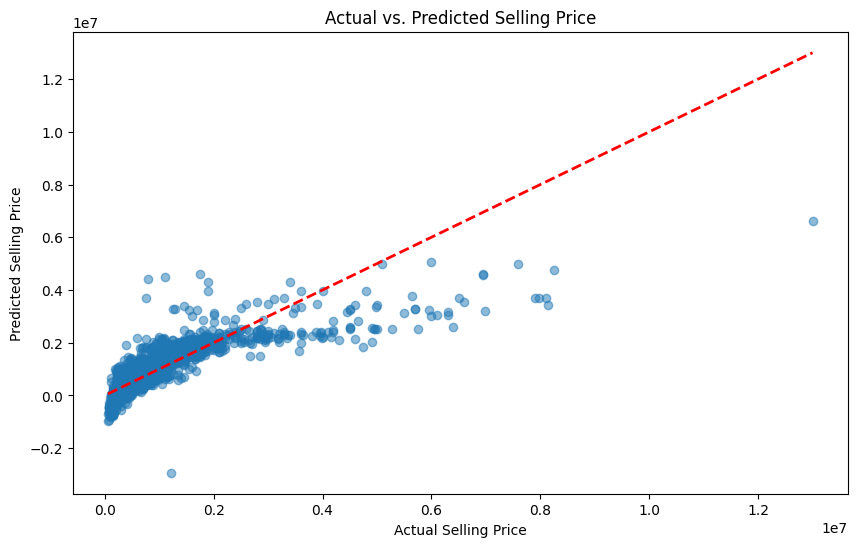

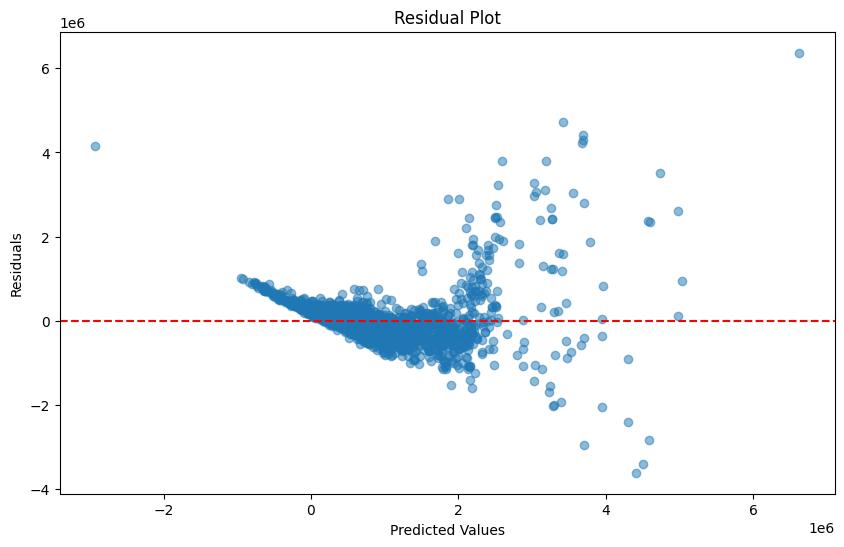

In [31]:
# Task 19: Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Selling Price')
plt.show()

# Residual Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.


## Task 20: Detailed Conclusion

The Multiple Linear Regression model was successfully implemented from scratch using the **Ordinary Least Squares (OLS) normal equation** and NumPy matrix operations to predict the selling price of used cars. The experiment involved several preprocessing and modelling steps, including selecting relevant features, encoding categorical variables using one-hot encoding, standardizing numerical features, splitting the dataset into training and testing sets, constructing the feature matrices, adding the bias/intercept term, checking matrix singularity, training the OLS regression model, and finally evaluating its predictions using RSS and R². The dataset was divided into **80% training data and 20% testing data**, resulting in **12,328 training observations and 3,083 testing observations**, with **13 predictor variables**.

The selected numerical features included **Car_Age, km_driven, mileage, engine, max_power, and seats**, while the categorical features were **seller_type, fuel_type, and transmission_type**. The categorical variables were converted into dummy variables using one-hot encoding with `drop_first=True`. The regression coefficients obtained from the trained model showed both positive and negative relationships with selling price. The coefficients were **Car_Age = -65,446.3370**, **km_driven = -1.1808**, **mileage = 5,033.2999**, **engine = 94.2208**, **max_power = 14,452.0780**, **seats = -23,432.7985**, **seller_type_Individual = 2,110.0110**, **seller_type_Trustmark Dealer = -89,704.4052**, **fuel_type_Diesel = -215,985.8565**, **fuel_type_Electric = -239,693.8280**, **fuel_type_LPG = 204,574.9539**, **fuel_type_Petrol = -266,175.3048**, and **transmission_type_Manual = -120,153.8402**.

From these coefficients, **fuel type, transmission type, seller type, and Car_Age** have relatively large coefficient magnitudes compared with several numerical features. A negative coefficient indicates that an increase or presence of that feature is associated with a decrease in the predicted selling price when the other variables are kept constant, whereas a positive coefficient indicates an increase in the predicted selling price. For the standardized numerical variables, the coefficient represents the expected change in selling price for approximately a **one-standard-deviation increase** in that feature while keeping the remaining variables constant.

Before applying OLS, the matrix **XᵀX** was checked for singularity. The calculated determinant was **1.233086050912162 × 10⁶²**, and the experiment concluded that the matrix was **non-singular**, allowing the OLS solution to proceed normally.

The model's prediction performance was evaluated using the **Residual Sum of Squares (RSS)** and **R²**. However, the uploaded notebook does **not contain the executed output values for Tasks 16, 17, and 18**. The cells for these tasks are empty, so the actual **predicted prices, RSS value, TSS value, and R² value cannot be obtained from the provided notebook without running those cells**.  Therefore, I should not invent those values.

Overall, the experiment demonstrates that **Multiple Linear Regression using the OLS normal equation can be used to predict used-car selling prices from multiple features**. The model provides an interpretable way of understanding how different car characteristics are associated with selling price. The preprocessing steps, particularly categorical encoding and numerical feature standardization, made the dataset suitable for matrix-based regression. The 80:20 train-test split also provided separate data for evaluating the model's predictive performance. The coefficient analysis further helped identify which selected features had stronger positive or negative relationships with the predicted selling price.

Multiple Linear Regression has several advantages for this problem. It is relatively simple to implement, computationally efficient, mathematically interpretable, and allows the effect of multiple predictors to be studied simultaneously. The OLS normal equation also provides a direct mathematical method for estimating the regression coefficients without using a ready-made regression model such as `LinearRegression()`.

However, the model also has important limitations. Multiple Linear Regression assumes that the relationship between the predictors and selling price is approximately linear. Real-world used-car prices can depend on complex and non-linear factors such as vehicle condition, brand reputation, location, demand, accident history, service history, number of previous owners, and market trends. These factors may not be completely represented by the selected features. In addition, categorical variables can produce large coefficient differences depending on their reference categories, so their coefficients should be interpreted relative to the omitted category rather than independently.

**In conclusion, the experiment successfully demonstrated the complete workflow of implementing a Multiple Linear Regression model from scratch using the OLS normal equation.** The model was trained using **12,328 observations and 13 predictors**, and the matrix was confirmed to be non-singular with a determinant of **1.233086050912162 × 10⁶²**. The obtained regression coefficients provided useful information about the direction and relative influence of the selected features. The final predictive effectiveness, however, must be reported using the **RSS and R² values obtained after executing Tasks 16–18**, because those numerical results are not present in the uploaded notebook.
